In [1]:
from pycbc.workflow import WorkflowConfigParser
from pycbc.inference.models.gaussian_noise import GaussianNoise
from pycbc.inference.models.marginalized_gaussian_noise import MarginalizedHMPhase
from pycbc.inference.models import read_from_config
import h5py
import numpy as np
import matplotlib.pyplot as plt

/Users/vikasjadhav/anaconda3/envs/hmphasemarg/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


In [2]:
population = 'general' ## ['general','hm']

In [3]:
dom = h5py.File(f'../outputs/mode_2233/vec_dominant/{population}/results/combined_output.hdf','r')
all_ = h5py.File(f'../outputs/mode_2233/vec_all/{population}/results/combined_output.hdf','r')
dom_first = h5py.File(f'../outputs/mode_2233/vec_dominant_first/{population}/results/combined_output.hdf','r')
all_first = h5py.File(f'../outputs/mode_2233/vec_all_first/{population}/results/combined_output.hdf','r')

quad = h5py.File(f'../outputs/mode_2233/quad/noise_{population}/combined_output.hdf','r')
grid = h5py.File(f'../outputs/mode_2233/grid/noise_{population}/results/combined_output.hdf','r')


In [4]:
N_inj = 500
dphi_22 = np.zeros(N_inj)
dphi_lm = np.zeros(N_inj)
snr = np.zeros(N_inj)
f_3 = np.zeros(N_inj)
q = np.zeros(N_inj)
inc = np.zeros(N_inj)
loglr = {'dom' : np.zeros(N_inj),
         'all' : np.zeros(N_inj),
         'dom_first' : np.zeros(N_inj),
         'all_first' : np.zeros(N_inj),
         'quad' : np.zeros(N_inj),
         'grid' : np.zeros(N_inj)}
for i in range(0,N_inj):
    inj = h5py.File(f'../injections/general_pop/injection_{i}.hdf')
    ## Calculate difference in phase
    true_phase = inj['coa_phase'][0]
    #print(inj['mass1'][0],inj['mass2'][0])
    q[i] = inj['mass1'][0]/inj['mass2'][0]
    inc[i] = inj['inclination'][0]
    phi_lm_peaks = np.array(all_[f'injection_{i}']['peaks'])
    phi_22_peaks = np.array(dom[f'injection_{i}']['peaks'])
    dphi_lm[i] = np.min(np.abs(true_phase - phi_lm_peaks))
    dphi_22[i] = np.min(np.abs(true_phase - phi_22_peaks))
    ## SNR and mode fraction = \rho_{33}/\rho_{tot}
    shm = all_[f'injection_{i}']['shm']
    snr[i] = np.sqrt(np.abs(shm['2'][()] + shm['3'][()]))
    f_3[i] = np.sqrt(np.abs(shm['3'][()]))/(np.sqrt(np.abs(shm['2'][()] + shm['3'][()])))
    loglr['dom'][i] = dom[f'injection_{i}']['loglr'][()]
    loglr['all'][i] = all_[f'injection_{i}']['loglr'][()]
    loglr['dom_first'][i] = dom_first[f'injection_{i}']['loglr'][()]
    loglr['all_first'][i] = all_first[f'injection_{i}']['loglr'][()]
    loglr['quad'][i] = quad[f'injection_{i}']['loglr'][()]
    loglr['grid'][i] = grid[f'injection_{i}']['loglr'][()]
    

def log_rel_err(log_approx, log_true):
    """
    Calculates absolute relative error between approx and true values
    |approx-true|/true
    Vectorized to accept scalars or arrays.
    """
    log_approx = np.asarray(log_approx)
    log_true = np.asarray(log_true)
    delta = log_approx - log_true
    result = np.where(delta > 0,
                      np.log10(np.exp(delta) - 1),
                      np.log10(1 - np.exp(delta)))
    return result

errors = {
    'dom' : log_rel_err(loglr['dom'],loglr['quad']),
    'all' : log_rel_err(loglr['all'],loglr['quad']),
    'dom_first' : log_rel_err(loglr['dom_first'],loglr['quad']),
    'all_first' : log_rel_err(loglr['all_first'],loglr['quad']),
    'grid' : log_rel_err(loglr['grid'],loglr['quad'])
}

#print(loglr)
#print(errors)

/var/folders/nx/6_stvkg90lz1ry25w8tttrh80000gn/T/ipykernel_54990/3234811172.py:47: RuntimeWarning: invalid value encountered in log10
  np.log10(np.exp(delta) - 1),
/var/folders/nx/6_stvkg90lz1ry25w8tttrh80000gn/T/ipykernel_54990/3234811172.py:48: RuntimeWarning: invalid value encountered in log10
  np.log10(1 - np.exp(delta)))


In [5]:
mask = errors['dom'] > 0
errors['dom'][mask]

array([        inf, 25.42443282,  8.61178357, 12.11497532, 14.85904553,
       61.7250016 , 15.39272072, 14.41246747, 22.70563316, 14.37085156,
       11.11702825,  8.03294173, 31.48772636,  9.70611218, 31.1595666 ,
        8.20927411, 10.01203492])

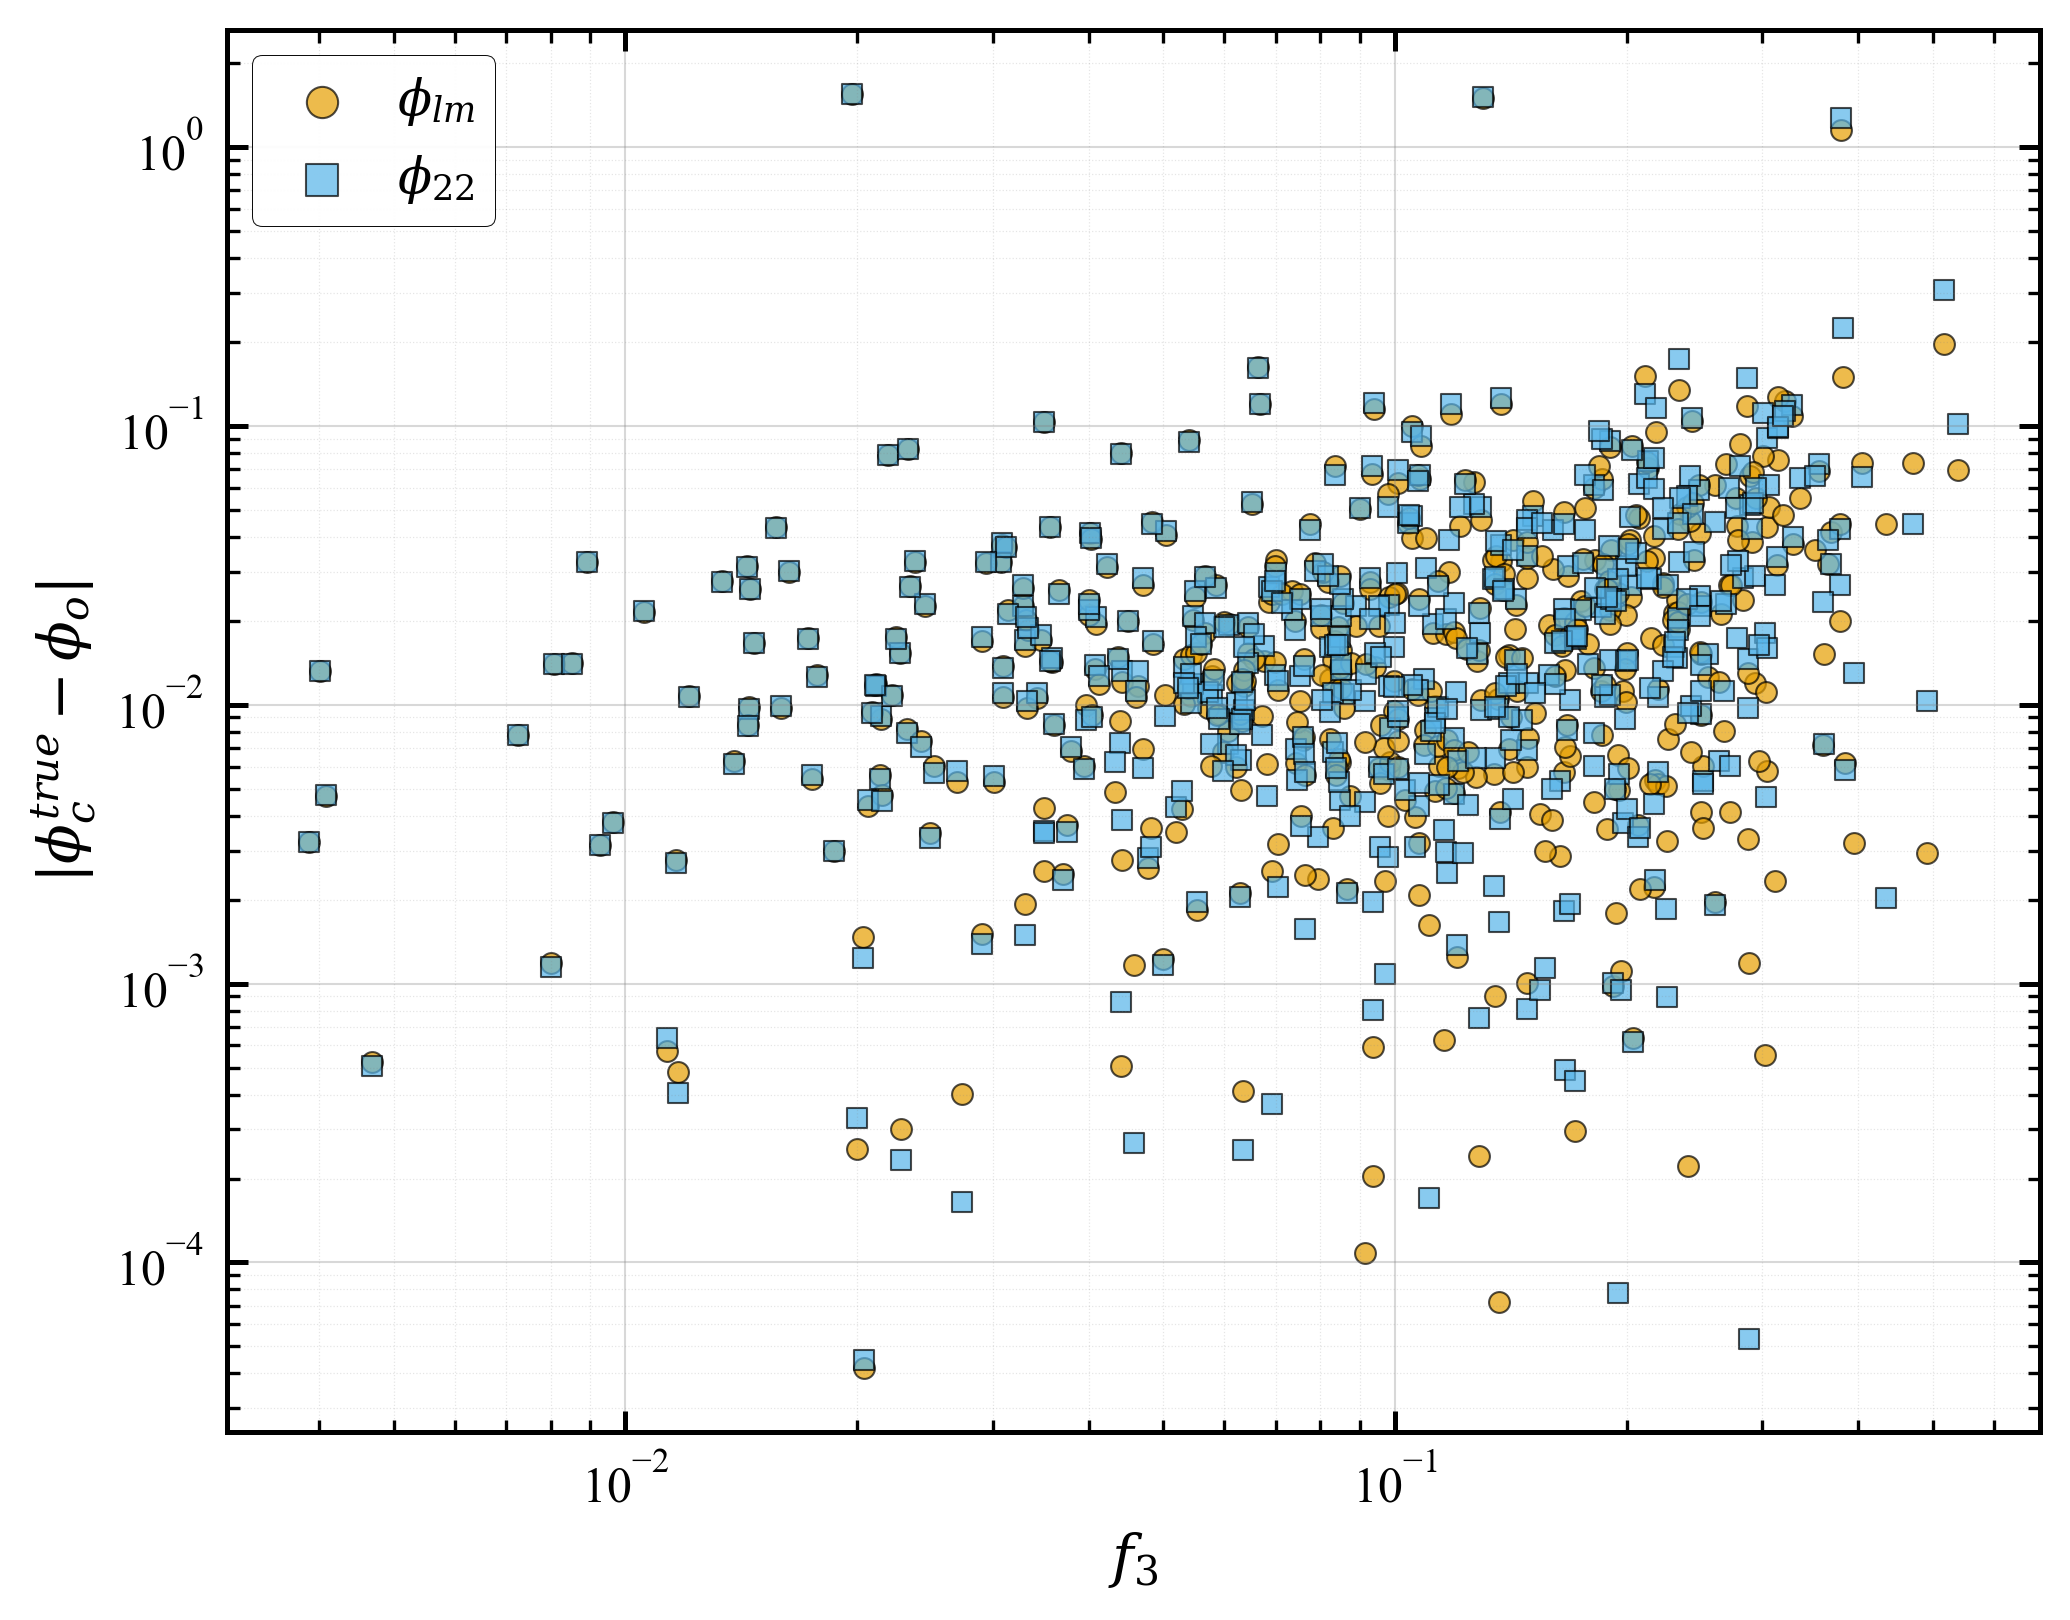

In [6]:
import matplotlib as mpl

# Set publication-quality style
plt.style.use('seaborn-v0_8-paper')
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
mpl.rcParams['mathtext.fontset'] = 'dejavuserif'
mpl.rcParams['axes.linewidth'] = 1.2
mpl.rcParams['xtick.major.width'] = 1.2
mpl.rcParams['ytick.major.width'] = 1.2
mpl.rcParams['xtick.minor.width'] = 0.8
mpl.rcParams['ytick.minor.width'] = 0.8
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['ytick.minor.size'] = 3

# Create figure with appropriate size for journal (single column ~3.5", double column ~7")
fig, ax = plt.subplots(figsize=(7, 5.5), dpi=300)

colors = ['#E69F00', '#56B4E9']  
markers = ['o', 's']
size = 25

ax.scatter(
    f_3, dphi_lm,
    label = r'$\phi_{lm}$',
    s = size, alpha=0.7,
    color = colors[0],
    marker=markers[0],
    edgecolors='black',
    linewidths=0.5
)

ax.scatter(
    f_3, dphi_22,
    label = r'$\phi_{22}$',
    s = size, alpha=0.7,
    color = colors[1],
    marker=markers[1],
    edgecolors='black',
    linewidths=0.5
)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$f_{3}$', fontsize=14)
ax.set_ylabel(r'$|\phi_{c}^{true} - \phi_{o}|$', fontsize=14)

ax.tick_params(labelsize=12, which='both', direction='in', top=True, right=True)

ax.grid(True, which='major', linestyle='-', linewidth=0.5, alpha=0.3, color='gray')
ax.grid(True, which='minor', linestyle=':', linewidth=0.3, alpha=0.2, color='gray')

ax.legend(loc='best', frameon=True, framealpha=0.95, 
          edgecolor='black', fontsize=12, 
          markerscale=1.5, handletextpad=0.5)

ax.set_facecolor('white')
fig.patch.set_facecolor('white')

plt.tight_layout()

plt.show()

# fig.savefig('figure.pdf', dpi=300, bbox_inches='tight', format='pdf')
#fig.savefig(f'peak_finding_{population}.png', dpi=300, bbox_inches='tight')

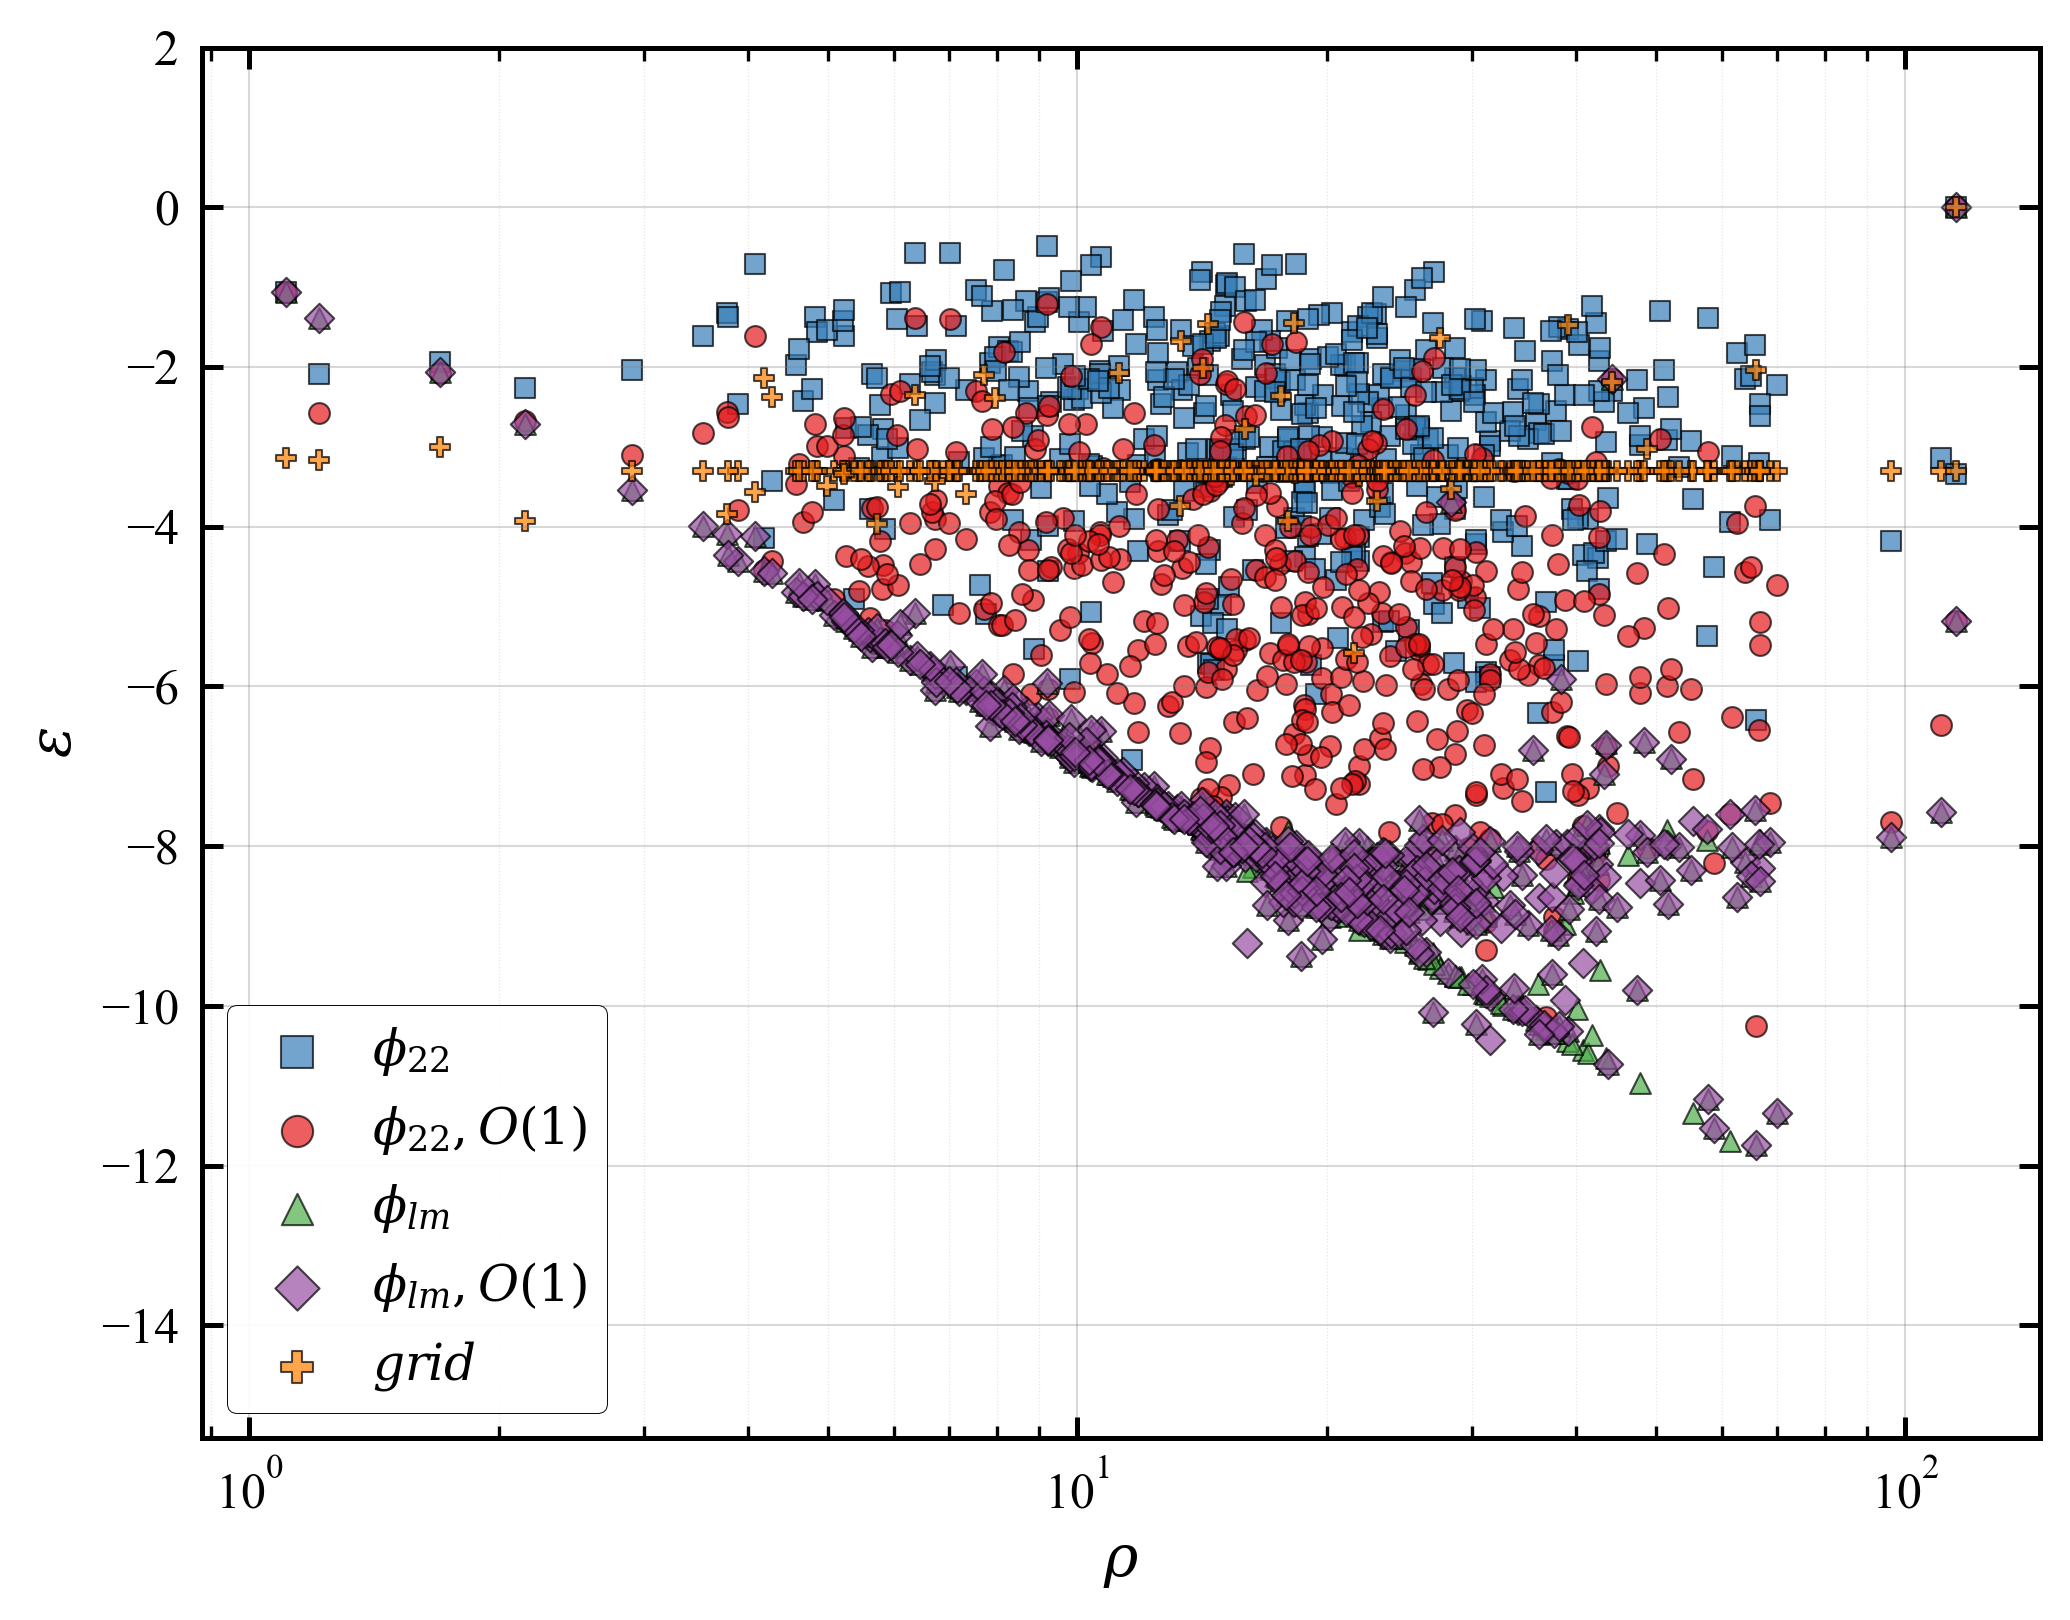

In [7]:
import matplotlib as mpl

# Set publication-quality style
plt.style.use('seaborn-v0_8-paper')
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
mpl.rcParams['mathtext.fontset'] = 'dejavuserif'
mpl.rcParams['axes.linewidth'] = 1.2
mpl.rcParams['xtick.major.width'] = 1.2
mpl.rcParams['ytick.major.width'] = 1.2
mpl.rcParams['xtick.minor.width'] = 0.8
mpl.rcParams['ytick.minor.width'] = 0.8
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['ytick.minor.size'] = 3

# Create figure with appropriate size for journal (single column ~3.5", double column ~7")
fig, ax = plt.subplots(figsize=(7, 5.5), dpi=300)

colors = ['#377EB8','#E41A1C','#4DAF4A','#984EA3','#FF7F00']
markers = ['s', 'o','^','D', 'P']
size = 25

ax.scatter(
    snr, errors['dom'],
    label = r'$\phi_{22}$',
    s = size, alpha=0.7,
    color = colors[0],
    marker=markers[0],
    edgecolors='black',
    linewidths=0.5
)

ax.scatter(
    snr, errors['dom_first'],
    label = r'$\phi_{22}, O(1)$',
    s = size, alpha=0.7,
    color = colors[1],
    marker=markers[1],
    edgecolors='black',
    linewidths=0.5
)

ax.scatter(
    snr, errors['all'],
    label = r'$\phi_{lm}$',
    s = size, alpha=0.7,
    color = colors[2],
    marker=markers[2],
    edgecolors='black',
    linewidths=0.5
)

ax.scatter(
    snr, errors['all_first'],
    label = r'$\phi_{lm}, O(1)$',
    s = size, alpha=0.7,
    color = colors[3],
    marker=markers[3],
    edgecolors='black',
    linewidths=0.5
)


ax.scatter(
    snr, errors['grid'],
    label = r'$grid$',
    s = size, alpha=0.7,
    color = colors[4],
    marker=markers[4],
    edgecolors='black',
    linewidths=0.5
)
ax.set_xscale('log')
#ax.set_yscale('log')
ax.set_xlabel(r'$\rho$', fontsize=14)
ax.set_ylabel(r'$\epsilon$', fontsize=14)
ax.set_ylim(top=2)
ax.tick_params(labelsize=12, which='both', direction='in', top=True, right=True)

ax.grid(True, which='major', linestyle='-', linewidth=0.5, alpha=0.3, color='gray')
ax.grid(True, which='minor', linestyle=':', linewidth=0.3, alpha=0.2, color='gray')

ax.legend(loc='best', frameon=True, framealpha=0.95, 
          edgecolor='black', fontsize=12, 
          markerscale=1.5, handletextpad=0.5)

ax.set_facecolor('white')
fig.patch.set_facecolor('white')

plt.tight_layout()

plt.show()

#fig.savefig('error_vs_snr.png', dpi=300, bbox_inches='tight')


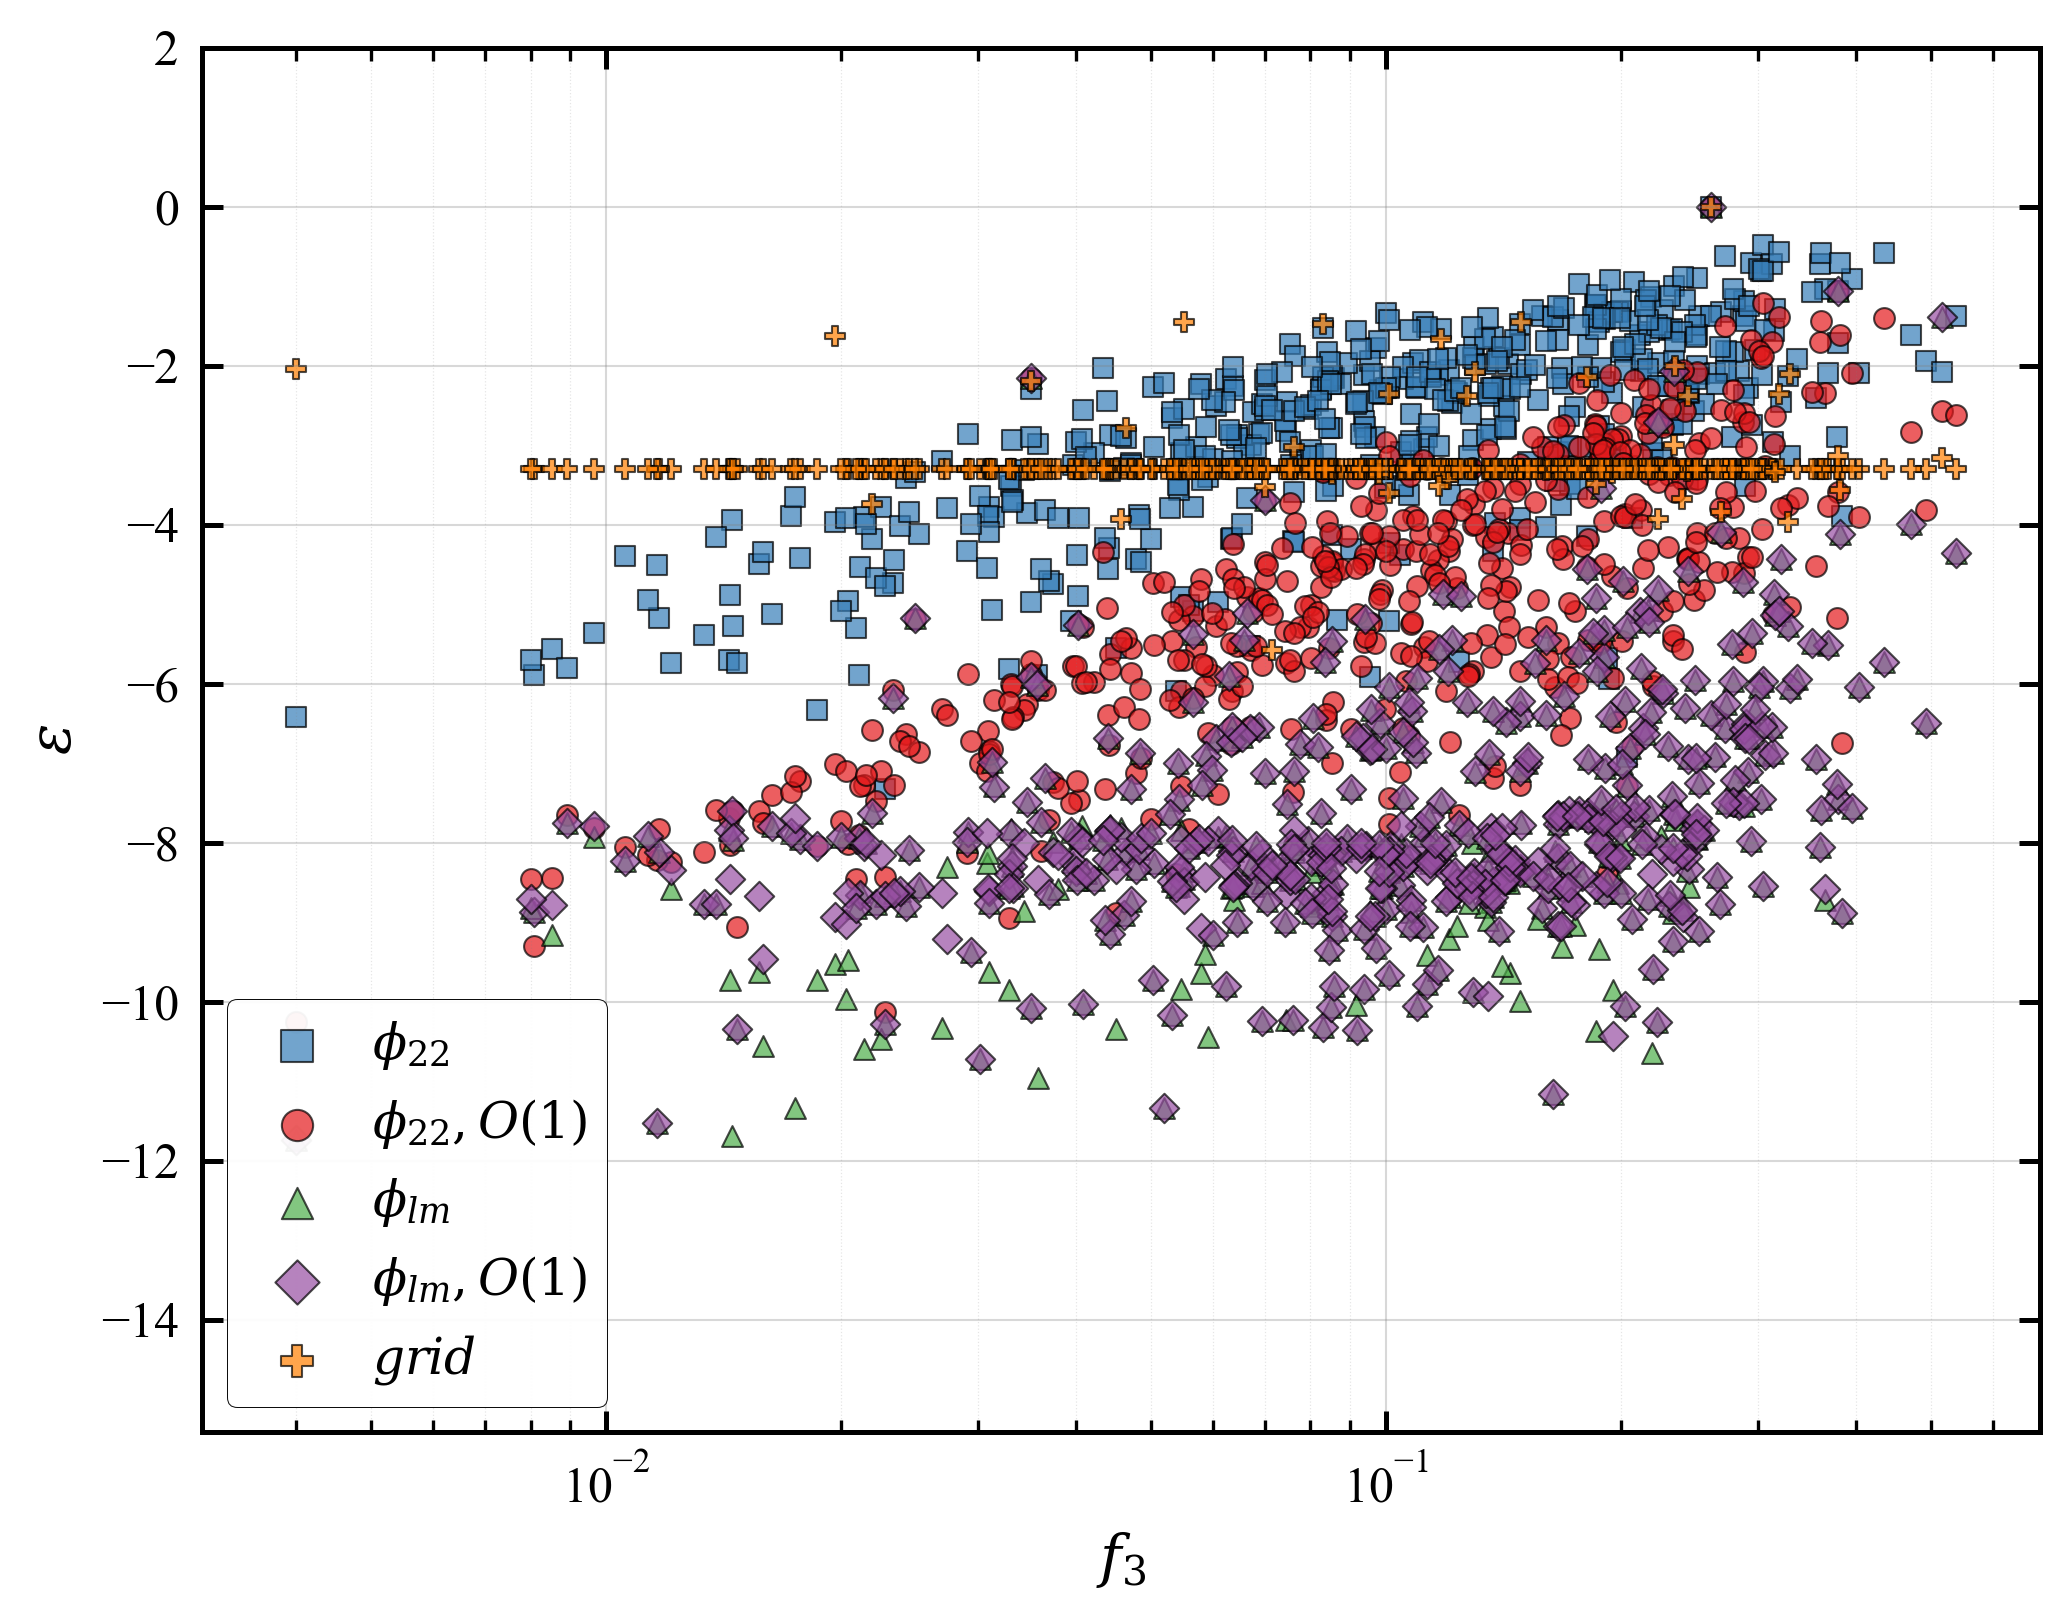

In [11]:
import matplotlib as mpl

# Set publication-quality style
plt.style.use('seaborn-v0_8-paper')
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
mpl.rcParams['mathtext.fontset'] = 'dejavuserif'
mpl.rcParams['axes.linewidth'] = 1.2
mpl.rcParams['xtick.major.width'] = 1.2
mpl.rcParams['ytick.major.width'] = 1.2
mpl.rcParams['xtick.minor.width'] = 0.8
mpl.rcParams['ytick.minor.width'] = 0.8
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['ytick.minor.size'] = 3

# Create figure with appropriate size for journal (single column ~3.5", double column ~7")
fig, ax = plt.subplots(figsize=(7, 5.5), dpi=300)
 
colors = ['#377EB8','#E41A1C','#4DAF4A','#984EA3','#FF7F00']
markers = ['s', 'o','^','D', 'P']
size = 25

ax.scatter(
    f_3, errors['dom'],
    label = r'$\phi_{22}$',
    s = size, alpha=0.7,
    color = colors[0],
    marker=markers[0],
    edgecolors='black',
    linewidths=0.5
)

ax.scatter(
    f_3, errors['dom_first'],
    label = r'$\phi_{22}, O(1)$',
    s = size, alpha=0.7,
    color = colors[1],
    marker=markers[1],
    edgecolors='black',
    linewidths=0.5
)

ax.scatter(
    f_3, errors['all'],
    label = r'$\phi_{lm}$',
    s = size, alpha=0.7,
    color = colors[2],
    marker=markers[2],
    edgecolors='black',
    linewidths=0.5
)

ax.scatter(
    f_3, errors['all_first'],
    label = r'$\phi_{lm}, O(1)$',
    s = size, alpha=0.7,
    color = colors[3],
    marker=markers[3],
    edgecolors='black',
    linewidths=0.5
)

ax.scatter(
    f_3, errors['grid'],
    label = r'$grid$',
    s = size, alpha=0.7,
    color = colors[4],
    marker=markers[4],
    edgecolors='black',
    linewidths=0.5
)

ax.set_xscale('log')
#ax.set_yscale('log')
ax.set_xlabel(r'$f_{3}$', fontsize=14)
ax.set_ylabel(r'$\epsilon$', fontsize=14)
ax.set_ylim(top=2)
ax.tick_params(labelsize=12, which='both', direction='in', top=True, right=True)

ax.grid(True, which='major', linestyle='-', linewidth=0.5, alpha=0.3, color='gray')
ax.grid(True, which='minor', linestyle=':', linewidth=0.3, alpha=0.2, color='gray')

ax.legend(loc='best', frameon=True, framealpha=0.95, 
          edgecolor='black', fontsize=12, 
          markerscale=1.5, handletextpad=0.5)

ax.set_facecolor('white')
fig.patch.set_facecolor('white')

plt.tight_layout()

plt.show()


#fig.savefig('error_vs_f3.png', dpi=300, bbox_inches='tight')

In [47]:
prob = np.where(errors['all']>0)[0]
print(prob)

[  1 101 186 197 208 235 276 298 314 332 395 412 421 432 439 463 466]


In [55]:
for i in prob:
    pi = h5py.File(f'../injections/general_pop/injection_{i}.hdf')
    print('ditance',pi['distance'][()])
    print('snr',snr[i])
    print('f3',f_3[i])

ditance [103.6721816]
snr 135.28300595972397
f3 0.11949830926656639
ditance [308.79781445]
snr 48.65886448769182
f3 0.021456398306911352
ditance [803.67709545]
snr 35.571338008146526
f3 0.03566019258118074
ditance [992.03186179]
snr 37.351004824790024
f3 0.023209344146554782
ditance [410.98407928]
snr 37.490927431775205
f3 0.11670863326671907
ditance [428.37440639]
snr 90.13638637008899
f3 0.0628908809426016
ditance [610.47414409]
snr 90.46029557452631
f3 0.0038838170323993765
ditance [890.94583266]
snr 37.66876932335108
f3 0.04006156836626139
ditance [642.94758815]
snr 51.72743739501976
f3 0.10307975524709263
ditance [658.88776715]
snr 86.96528029613279
f3 0.020679464066095735
ditance [571.17940277]
snr 37.20244796555113
f3 0.08739994721027551
ditance [323.55416703]
snr 28.9665992282548
f3 0.033402221101373024
ditance [385.34203839]
snr 96.7176383511882
f3 0.0040831275899550715
ditance [838.89128092]
snr 33.18870910349032
f3 0.004684872578523316
ditance [368.65799389]
snr 109.43444123